# e28 Philadelphia Hybrid Sampling Full Test Analysis

Analysis of experiment `e28TR_philly_hybrid_sampling_full_test`, which trains TAGConv (100 epochs) and
SparseGT (100 epochs, sweep-tuned) on **hybrid-sampled** Philadelphia datasets across resolutions 1–20.

This notebook mirrors the structure of `e27_philly_hybrid_sampling.ipynb`, but uses the Philadelphia runs.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import wandb
import wandb_buddy as wb
from tqdm import tqdm

In [3]:
ENTITY = "alelab"
PROJECT = "terrains"
TAG = "e28TR_philly_hybrid_sampling_full_test"
ORIGINAL_DIM = 1000

## Helper functions

In [4]:
def extract_resolution(row):
    dataset_name = str(row["dataset_name"])
    res_match = re.search(r"res(\d+)", dataset_name)
    return int(res_match.group(1))


def get_metric_history_mean(entity, project, run_id, metric):
    api = wandb.Api()
    run = api.run(f"{entity}/{project}/{run_id}")
    history = run.history(keys=[metric], pandas=True)
    if history.empty or metric not in history.columns:
        return np.nan
    values = history[metric].dropna()
    return values.mean() if len(values) > 0 else np.nan


def add_metric_from_history(df, entity, project, source_metric, target_col):
    means = []
    for run_id in tqdm(df["id"], desc=f"Fetching {source_metric}"):
        means.append(get_metric_history_mean(entity, project, run_id, source_metric))
    df[target_col] = means
    return df

---
## Load runs

In [5]:
print(f"Fetching runs with tag: {TAG}")
df = wb.load_runs(ENTITY, PROJECT, tags=[TAG])
print(f"Found {len(df)} runs")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/teresa/.netrc.


Fetching runs with tag: e28TR_philly_hybrid_sampling_full_test
Found 60 runs


In [6]:
if "resolution" not in df.columns:
    if "dataset_name" in df.columns:
        df["resolution"] = df.apply(extract_resolution, axis=1)
    else:
        df["resolution"] = df["name"].str.extract(r"res(\d+)", expand=False).astype(float)

# Clean up type after extraction from either source
if df["resolution"].dtype != int:
    df = df.dropna(subset=["resolution"]).copy()
    df["resolution"] = df["resolution"].astype(int)

df = df[df["resolution"] >= 3].copy()

df["density"] = 1 / (df["resolution"] ** 2)
df["num_nodes"] = df["resolution"].apply(
    lambda r: ((ORIGINAL_DIM - 1) // r + 1) ** 2
)
print(f"Resolutions: {sorted(df['resolution'].unique())}")

Resolutions: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


In [7]:
print("Available columns:", df.columns.tolist())

if "layer_type" not in df.columns:
    df["layer_type"] = df["name"].str.extract(r"(TAGConv|SparseGT)", expand=False)
    print(f"Inferred layer_type from run name: {df['layer_type'].value_counts().to_dict()}")

api = wandb.Api()
embed_modes = {}
for _, row in tqdm(df[df["layer_type"] == "SparseGT"].iterrows(), desc="Fetching embedding_mode"):
    run = api.run(f"{ENTITY}/{PROJECT}/{row['id']}")
    embed_modes[row["id"]] = run.config.get("sparse_gt_embedding_mode", None)
df["sparse_gt_embedding_mode"] = df["id"].map(embed_modes)

def assign_model_label(row):
    if row["layer_type"] == "TAGConv":
        return "GNN"
    embed = row["sparse_gt_embedding_mode"]
    if embed == "random":
        return "SparseGT-Random"
    return "SparseGT-Data"

df["model_label"] = df.apply(assign_model_label, axis=1)

print(f"\nRuns with valid test_nmae: {df['test_nmae'].notna().sum()} / {len(df)}")
print(f"\nBy model_label:")
print(df.groupby("model_label")["test_nmae"].apply(lambda x: f"{x.notna().sum()}/{len(x)} valid"))

Available columns: ['name', 'id', 'state', 'created_at', 'heartbeat_at', 'tags', 'sweep_id', '_runtime', '_step', '_timestamp', '_wandb', 'best_val_mae', 'epoch', 'final_train_acc_1pct', 'final_train_acc_2pct', 'final_train_acc_5pct', 'final_train_loss', 'final_train_mae', 'final_train_mse', 'final_train_nmae', 'global_step', 'p', 'test_acc_1pct', 'test_acc_2pct', 'test_acc_5pct', 'test_batch_loss', 'test_batch_mae', 'test_batch_mse', 'test_batch_nmae', 'test_loss', 'test_mae', 'test_mse', 'test_nmae', 'train_loss', 'train_mae', 'train_mse', 'train_nmae', 'val_acc_1pct', 'val_acc_2pct', 'val_acc_5pct', 'val_loss', 'val_mae', 'val_mse', 'val_nmae', 'best_val_nmae', 'resolution', 'density', 'num_nodes']
Inferred layer_type from run name: {'SparseGT': 40, 'TAGConv': 18}


Fetching embedding_mode: 40it [00:14,  2.78it/s]


Runs with valid test_nmae: 58 / 58

By model_label:
model_label
GNN                18/18 valid
SparseGT-Data      18/18 valid
SparseGT-Random    22/22 valid
Name: test_nmae, dtype: object


---
## Best performance per resolution

In [8]:
df_valid_nmae = df.dropna(subset=["test_nmae"])
best_per_resolution_nmae = df_valid_nmae.loc[
    df_valid_nmae.groupby(["model_label", "resolution"])["test_nmae"].idxmin()
]

print(f"Best runs per resolution (NMAE): {len(best_per_resolution_nmae)}")

Best runs per resolution (NMAE): 54


In [9]:
cols = ["name", "model_label", "resolution", "num_nodes", "test_nmae", "epochs", "state"]
display_cols = [c for c in cols if c in best_per_resolution_nmae.columns]
best_per_resolution_nmae.sort_values(["model_label", "resolution"])[display_cols]

,name,model_label,resolution,num_nodes,test_nmae,state
54,terrain-graph-TAGConv-res03-stage1,GNN,3,111556,0.029638,finished
51,terrain-graph-TAGConv-res04-stage1,GNN,4,62500,0.030440,finished
53,terrain-graph-TAGConv-res05-stage1,GNN,5,40000,0.030173,finished
50,terrain-graph-TAGConv-res06-stage1,GNN,6,27889,0.031031,finished
49,terrain-graph-TAGConv-res07-stage1,GNN,7,20449,0.030063,finished
48,terrain-graph-TAGConv-res08-stage1,GNN,8,15625,0.029806,finished
47,terrain-graph-TAGConv-res09-stage1,GNN,9,12544,0.031272,finished
46,terrain-graph-TAGConv-res10-stage1,GNN,10,10000,0.029666,finished
45,terrain-graph-TAGConv-res11-stage1,GNN,11,8281,0.031065,finished
44,terrain-graph-TAGConv-res12-stage1,GNN,12,7056,0.031033,finished


---
## Transferability plot

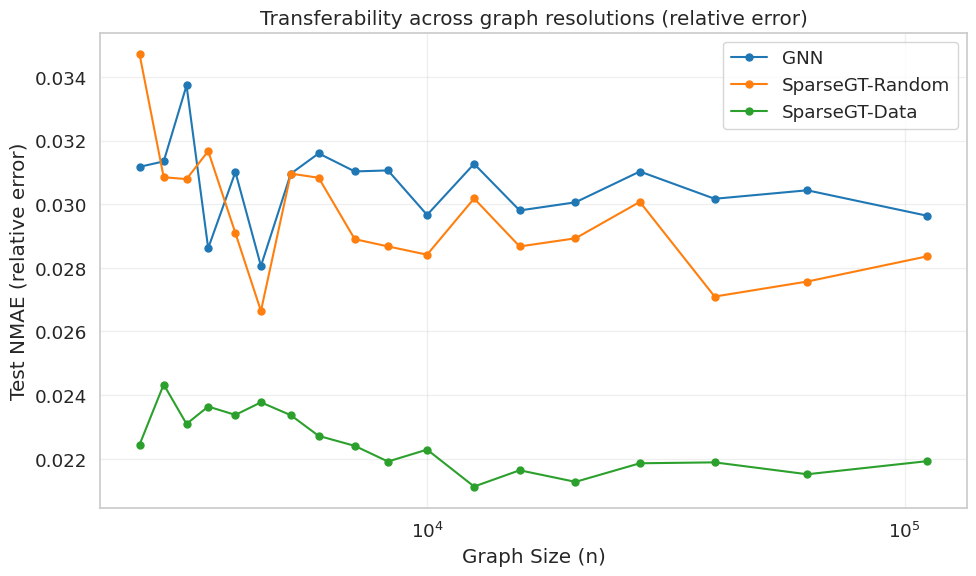

In [10]:
# Transferability plot in relative error (NMAE)
sns.set_theme(style="whitegrid", font_scale=1.2)

COLOR_MAP = {
    "GNN": "#1f77b4",
    "SparseGT-Random": "#ff7f0e",
    "SparseGT-Data": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(10, 6))

for label in ["GNN", "SparseGT-Random", "SparseGT-Data"]:
    data = best_per_resolution_nmae[
        best_per_resolution_nmae["model_label"] == label
    ].sort_values("num_nodes")

    if data.empty:
        continue

    ax.plot(
        data["num_nodes"], data["test_nmae"],
        marker="o", label=label, color=COLOR_MAP[label],
        linewidth=1.5, markersize=5,
    )

ax.set_xscale("log")
ax.set_xlabel("Graph Size (n)")
ax.set_ylabel("Test NMAE (relative error)")
ax.set_title("Transferability across graph resolutions (relative error)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## NMAE per distance group

In [11]:
import os

all_preds = []
for _, row in tqdm(best_per_resolution_nmae.iterrows(), desc="Loading predictions"):
    run = api.run(f"{ENTITY}/{PROJECT}/{row['id']}")
    log_dir = run.config.get("log_dir", None)
    if log_dir is None:
        continue
    preds_path = os.path.join(log_dir, "preds.csv")
    if not os.path.exists(preds_path):
        print(f"  Missing preds.csv for {row['name']} (res {row['resolution']})")
        continue
    preds_df = pd.read_csv(preds_path)
    preds_df["model_label"] = row["model_label"]
    preds_df["resolution"] = row["resolution"]
    preds_df["num_nodes"] = row["num_nodes"]
    all_preds.append(preds_df)

all_preds_df = pd.concat(all_preds, ignore_index=True)
all_preds_df = all_preds_df[all_preds_df["resolution"] >= 3]
print(f"Total predictions: {len(all_preds_df):,}")
print(f"Models: {sorted(all_preds_df['model_label'].unique())}")
print(f"Resolutions: {sorted(all_preds_df['resolution'].unique())}")

Loading predictions: 54it [00:08,  6.07it/s]


Total predictions: 2,686,500
Models: ['GNN', 'SparseGT-Data', 'SparseGT-Random']
Resolutions: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


/tmp/ipykernel_3060105/2294632333.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


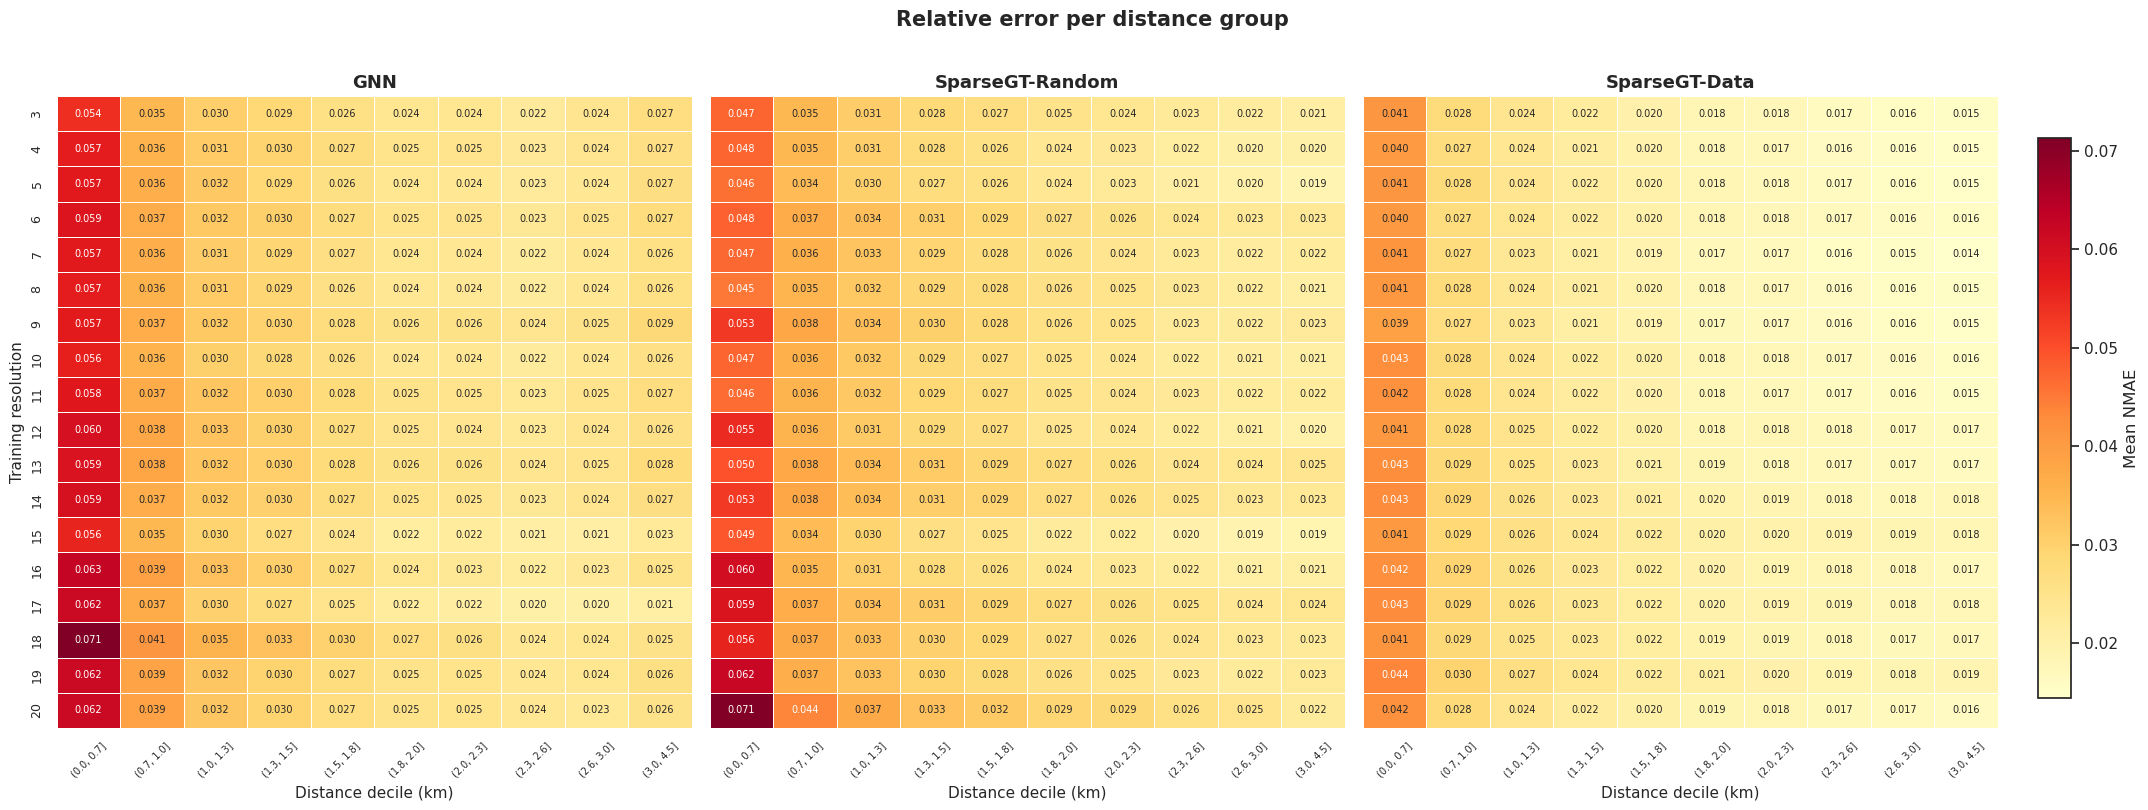

In [12]:
N_BINS = 10
all_preds_df["distance_group"] = pd.qcut(
    all_preds_df["lengths"], q=N_BINS, duplicates="drop"
)

nmae_by_group = (
    all_preds_df
    .groupby(["model_label", "resolution", "distance_group"], observed=False)["pred_nmaes"]
    .mean()
    .reset_index()
    .rename(columns={"pred_nmaes": "mean_nmae"})
)

def format_interval(iv):
    left = max(iv.left, 0.0)
    return f"({left:.1f}, {iv.right:.1f}]"

MODEL_ORDER = ["GNN", "SparseGT-Random", "SparseGT-Data"]
all_resolutions = sorted(all_preds_df["resolution"].unique())

sns.set_theme(style="white", font_scale=1.0)
fig, axes = plt.subplots(
    1, 3, figsize=(22, 8), sharey=True,
    gridspec_kw={"width_ratios": [1, 1, 1]},
)

vmin = nmae_by_group["mean_nmae"].min()
vmax = nmae_by_group["mean_nmae"].max()

for idx, model in enumerate(MODEL_ORDER):
    ax = axes[idx]
    subset = nmae_by_group[nmae_by_group["model_label"] == model]

    pivot = subset.pivot(
        index="resolution", columns="distance_group", values="mean_nmae"
    )
    pivot = pivot.reindex(index=all_resolutions)
    pivot.columns = [format_interval(c) for c in pivot.columns]

    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        vmin=vmin,
        vmax=vmax,
        annot=True,
        fmt=".3f",
        annot_kws={"size": 7},
        cbar=False,
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(model, fontsize=13, fontweight="bold")
    ax.set_xlabel("Distance decile (km)", fontsize=11)
    if idx == 0:
        ax.set_ylabel("Training resolution", fontsize=11)
    else:
        ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=9)

fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=vmin, vmax=vmax))
fig.colorbar(sm, cax=cbar_ax, label="Mean NMAE")

fig.suptitle("Relative error per distance group", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

In [15]:
from scipy.interpolate import griddata as sp_griddata

SPATIAL_RES = 10

spatial_runs = {}
for label in ["GNN", "SparseGT-Random", "SparseGT-Data"]:
    candidates = best_per_resolution_nmae[
        (best_per_resolution_nmae["model_label"] == label)
        & (best_per_resolution_nmae["resolution"] == SPATIAL_RES)
    ]
    if candidates.empty:
        print(f"  No run found for {label} at res {SPATIAL_RES}")
        continue
    row = candidates.sort_values("test_nmae").iloc[0]
    run_obj = api.run(f"{ENTITY}/{PROJECT}/{row['id']}")
    log_dir = run_obj.config.get("log_dir")
    test_data_path = run_obj.config.get("test_data")
    preds_path = os.path.join(log_dir, "preds.csv")
    if not os.path.exists(preds_path):
        print(f"  Missing preds.csv for {label}")
        continue
    preds_df = pd.read_csv(preds_path)
    spatial_runs[label] = {
        "preds": preds_df,
        "test_nmae": row["test_nmae"],
        "run_id": row["id"],
        "test_data_path": test_data_path,
    }
    print(f"  {label}: run={row['id']}, test_nmae={row['test_nmae']:.4f}, "
          f"preds={len(preds_df)}")

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

ref_label = list(spatial_runs.keys())[0]
test_npz_path = spatial_runs[ref_label]["test_data_path"]
if not os.path.isabs(test_npz_path):
    test_npz_path = os.path.join(REPO_ROOT, "data", test_npz_path)
print(f"\nLoading test graph from: {test_npz_path}")
test_data = np.load(test_npz_path, allow_pickle=True)
node_features = test_data["node_features"]  # (N, 3): x, y, z
print(f"Test graph: {node_features.shape[0]} nodes, {node_features.shape[1]} features")

all_x = np.unique(node_features[:, 0])
all_y = np.unique(node_features[:, 1])
grid_x, grid_y = np.meshgrid(all_x, all_y)
grid_nx, grid_ny = len(all_x), len(all_y)

ref_preds = spatial_runs[ref_label]["preds"]
src_ids = np.unique(ref_preds["srcs"].astype(int).values)
src_coords = node_features[src_ids, :2]
src_order = np.lexsort((src_coords[:, 0], src_coords[:, 1]))
sorted_srcs = src_ids[src_order]
n_sources_to_plot = min(9, len(sorted_srcs))
positions = np.linspace(0, len(sorted_srcs) - 1, n_sources_to_plot, dtype=int)
sources_to_plot = sorted_srcs[positions]
print(f"Sources to plot: {sources_to_plot.tolist()}")

  GNN: run=osxwtdss, test_nmae=0.0297, preds=49750
  SparseGT-Random: run=0v9m0ttm, test_nmae=0.0284, preds=49750
  SparseGT-Data: run=zd242yyv, test_nmae=0.0223, preds=49750

Loading test graph from: /home/teresa/shortest-paths-nn/data/generated2/philly_test_res04.npz
Test graph: 62500 nodes, 3 features
Sources to plot: [747, 6470, 13955, 22444, 32467, 40405, 48185, 53619, 62394]


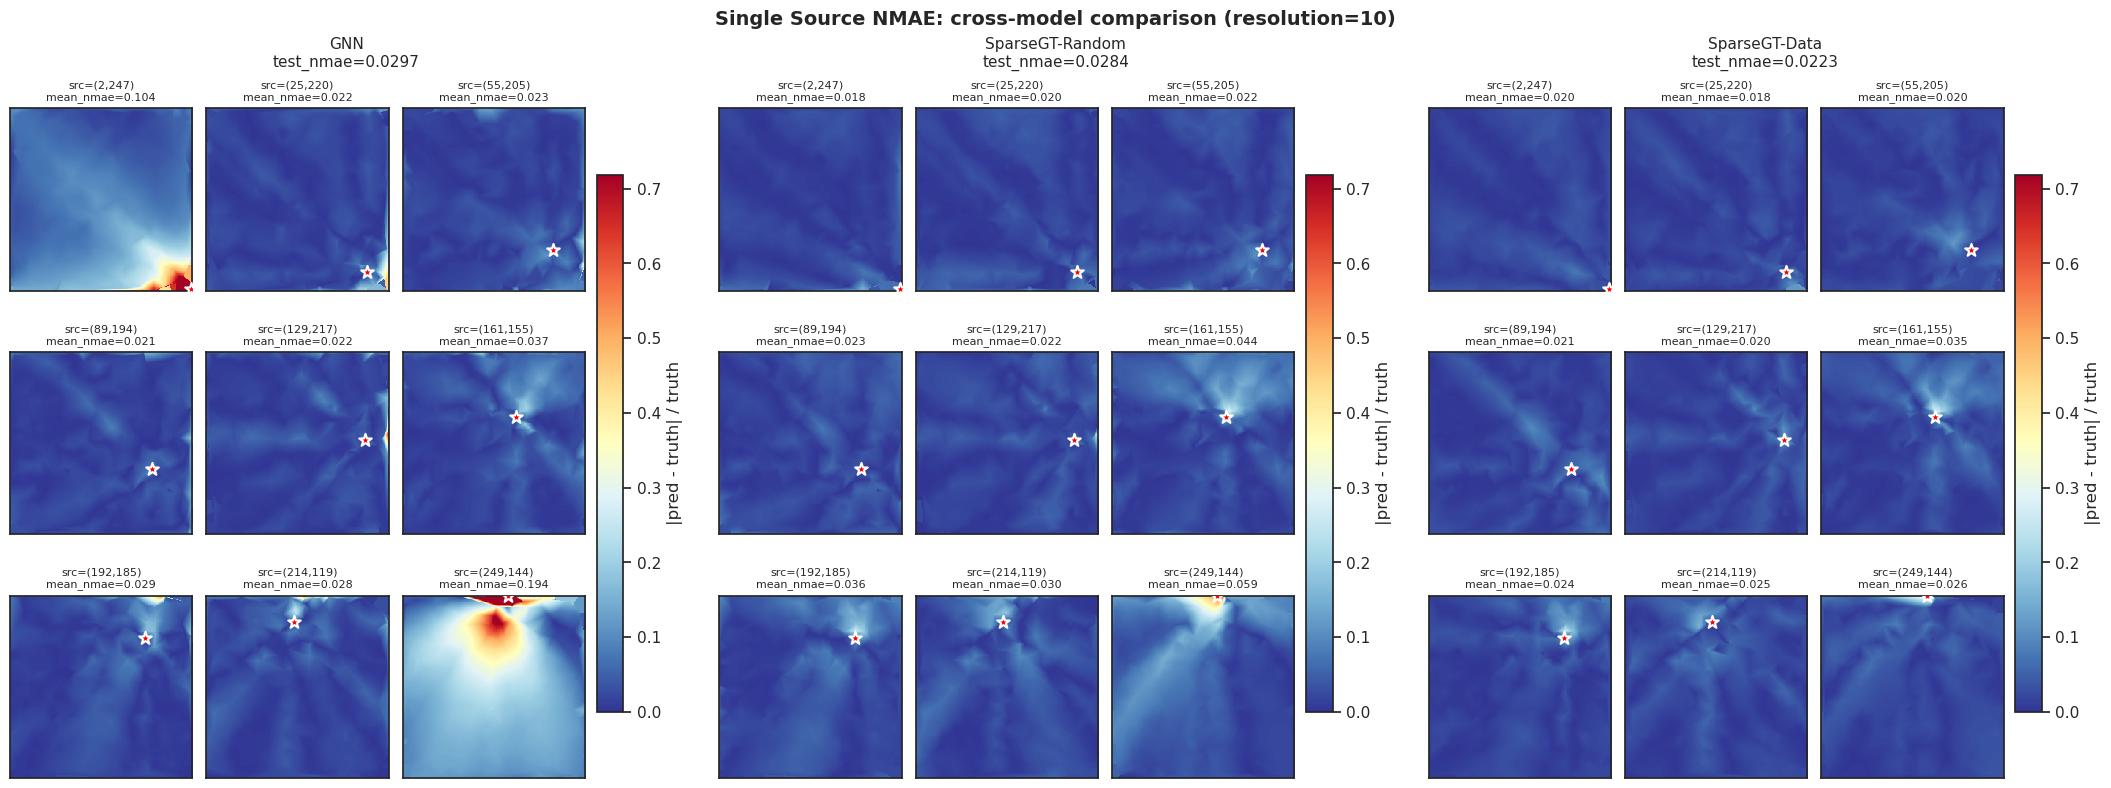

In [16]:
def build_nmae_maps(preds_df, sources, node_feats, gx, gy):
    pdf = preds_df.copy()
    pdf["srcs"] = pdf["srcs"].astype(int)
    pdf["tars"] = pdf["tars"].astype(int)
    maps, stats = [], []
    for src in sources:
        src = int(src)
        rows = pdf[pdf["srcs"] == src]
        tids = rows["tars"].to_numpy()
        txy = node_feats[tids, :2]
        errors = rows["pred_nmaes"].to_numpy()
        if len(txy) > 0:
            dl = sp_griddata(txy, errors, (gx, gy), method="linear")
            dn = sp_griddata(txy, errors, (gx, gy), method="nearest")
            d2d = np.where(np.isnan(dl), dn, dl)
        else:
            d2d = np.full(gx.shape, np.nan)
        sxy = node_feats[src, :2]
        sc = int(np.searchsorted(all_x, sxy[0]))
        sr = int(np.searchsorted(all_y, sxy[1]))
        me = rows["pred_nmaes"].mean() if len(rows) > 0 else np.nan
        maps.append(d2d)
        stats.append((sr, sc, me))
    return maps, stats

all_maps = {}
shared_vmin = 0
shared_vmax = 0
for label, rinfo in spatial_runs.items():
    m, s = build_nmae_maps(rinfo["preds"], sources_to_plot, node_features, grid_x, grid_y)
    all_maps[label] = (m, s)
    for d2d in m:
        v = np.nanpercentile(d2d, 99)
        if v > shared_vmax:
            shared_vmax = v

MODEL_ORDER = ["GNN", "SparseGT-Random", "SparseGT-Data"]
models_to_plot = [m for m in MODEL_ORDER if m in all_maps]
n_models = len(models_to_plot)

fig = plt.figure(figsize=(7 * n_models, 8), constrained_layout=True)
subfigs = fig.subfigures(1, n_models, wspace=0.04)
if n_models == 1:
    subfigs = [subfigs]

for idx, (subfig, label) in enumerate(zip(subfigs, models_to_plot)):
    dist_maps, source_stats = all_maps[label]
    axes = subfig.subplots(3, 3)
    axes_flat = axes.flatten()
    im = None

    for i, (d2d, (sr, sc, me)) in enumerate(zip(dist_maps, source_stats)):
        ax = axes_flat[i]
        im = ax.imshow(
            d2d, cmap="RdYlBu_r", origin="lower",
            vmin=shared_vmin, vmax=shared_vmax, interpolation="nearest",
        )
        ax.scatter(sc, sr, c="red", s=90, marker="*",
                   edgecolors="white", linewidths=1.5, zorder=5)
        ax.set_title(f"src=({sr},{sc})\nmean_nmae={me:.3f}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes_flat[len(sources_to_plot):]:
        ax.axis("off")

    test_nmae = spatial_runs[label]["test_nmae"]
    subfig.suptitle(f"{label}\ntest_nmae={test_nmae:.4f}", fontsize=11)
    subfig.colorbar(im, ax=list(axes_flat), label="|pred - truth| / truth",
                    shrink=0.75, pad=0.02)

fig.suptitle(
    f"Single Source NMAE: cross-model comparison (resolution={SPATIAL_RES})",
    fontsize=14, fontweight="bold",
)
plt.show()